In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


In [48]:
df = pd.read_csv("../data/diabetes.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [49]:
print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Last 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [50]:
print("Column names:")
print(df.columns.tolist())

print("Data types:")
print(df.dtypes)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [52]:
target = "Outcome"

print("Target variable:", target)

print("\nClass distribution:")
print(df[target].value_counts())

print("\nClass percentages:")
print((df[target].value_counts(normalize=True) * 100).round(2))

Target variable: Outcome

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class percentages:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


In [53]:
numerical_features = df.drop(columns=["Outcome"]).select_dtypes(include=np.number).columns.tolist()
categorical_features = df.drop(columns=["Outcome"]).select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Categorical features:
[]


## Feature Description

| Feature | Description |
|---|---|
| Pregnancies | Number of times the patient has been pregnant |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure |
| SkinThickness | Triceps skin fold thickness |
| Insulin | 2-Hour serum insulin level |
| BMI | Body Mass Index |
| DiabetesPedigreeFunction | Diabetes pedigree function, representing a measure of diabetes-related family history |
| Age | Age of the patient |
| Outcome | Target variable: 0 = Non-diabetic, 1 = Diabetic |

In [54]:
eda_stats = df.drop(columns=["Outcome"]).agg(
    ["mean", "median", "std", "min", "max"]
).T

eda_stats

,mean,median,std,min,max
Pregnancies,3.845052,3.0000,3.369578,0.000,17.00
Glucose,120.894531,117.0000,31.972618,0.000,199.00
BloodPressure,69.105469,72.0000,19.355807,0.000,122.00
SkinThickness,20.536458,23.0000,15.952218,0.000,99.00
Insulin,79.799479,30.5000,115.244002,0.000,846.00
BMI,31.992578,32.0000,7.884160,0.000,67.10
DiabetesPedigreeFunction,0.471876,0.3725,0.331329,0.078,2.42
Age,33.240885,29.0000,11.760232,21.000,81.00


In [55]:
# Descriptive Statistics

descriptive_stats = df.describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


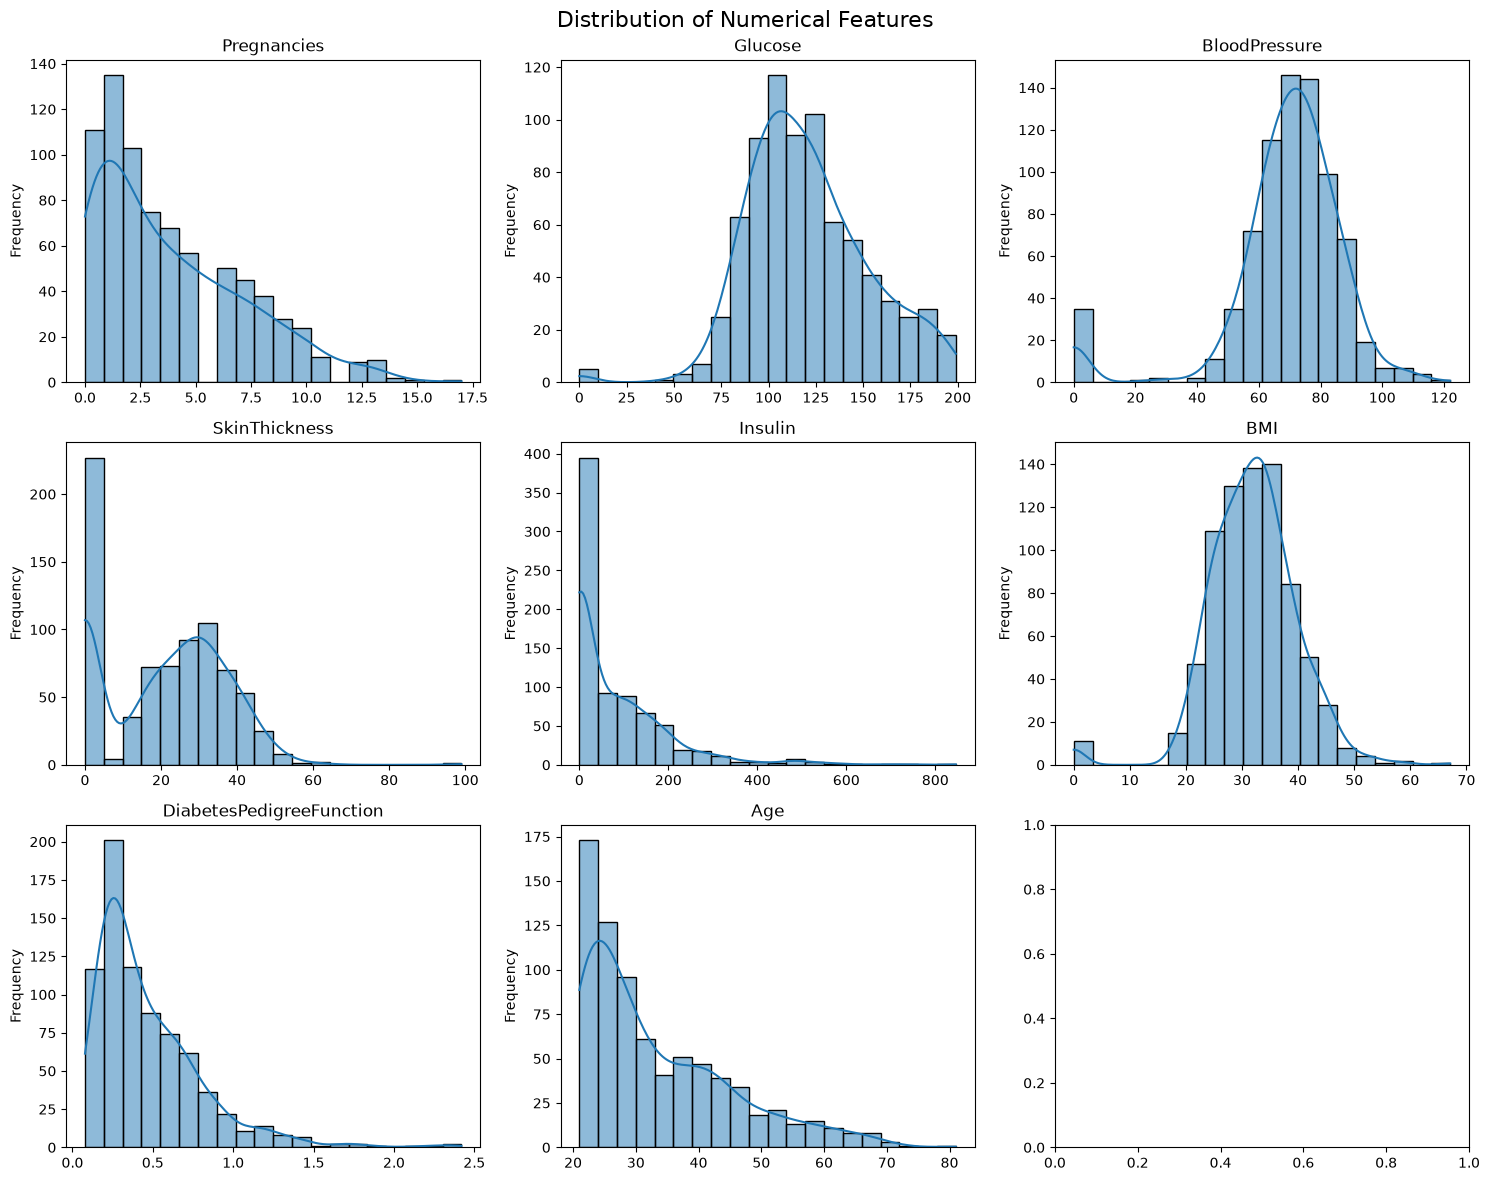

In [56]:
features = df.drop(columns=["Outcome"]).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True,
        edgecolor="black",
        ax=axes[i]
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

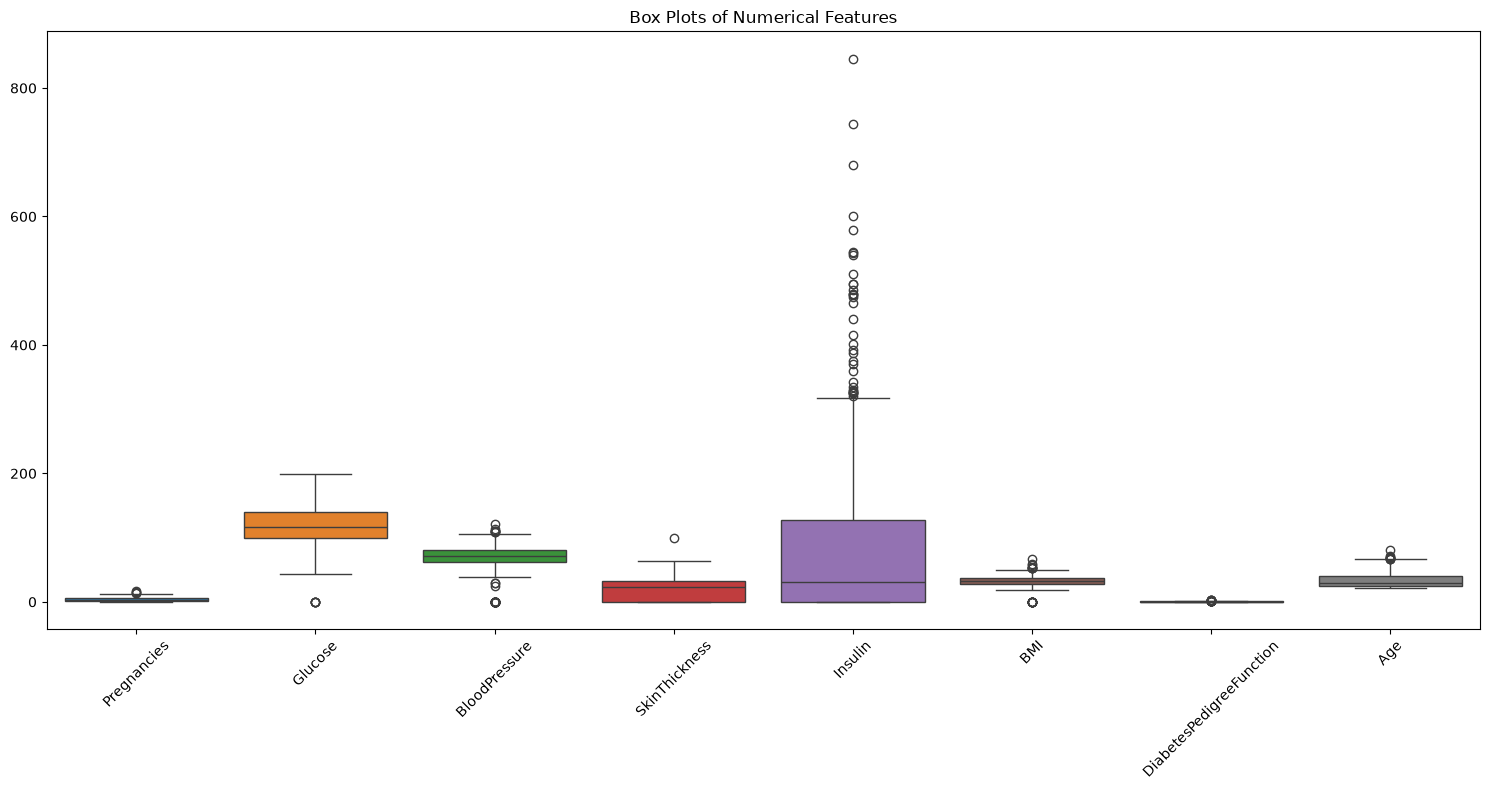

In [57]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df.drop(columns=["Outcome"]))

plt.title("Box Plots of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
skewness = df.drop(columns=["Outcome"]).skew().sort_values(ascending=False)

print("Skewness of numerical features:")
print(skewness)

Skewness of numerical features:
Insulin                     2.272251
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
Glucose                     0.173754
SkinThickness               0.109372
BMI                        -0.428982
BloodPressure              -1.843608
dtype: float64


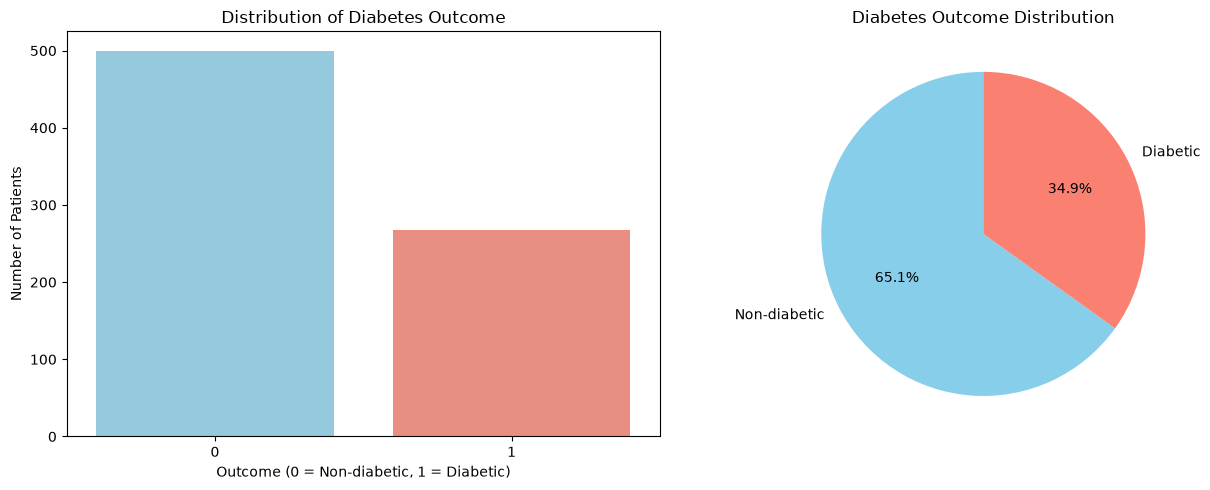

In [59]:
# Diabetes Outcome Distribution — Count Plot and Pie Chart

outcome_counts = df["Outcome"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count Plot
sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",
    palette=["skyblue", "salmon"],
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Distribution of Diabetes Outcome")
axes[0].set_xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
axes[0].set_ylabel("Number of Patients")

# Pie Chart
axes[1].pie(
    outcome_counts,
    labels=["Non-diabetic", "Diabetic"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "salmon"]
)

axes[1].set_title("Diabetes Outcome Distribution")

plt.tight_layout()
plt.show()

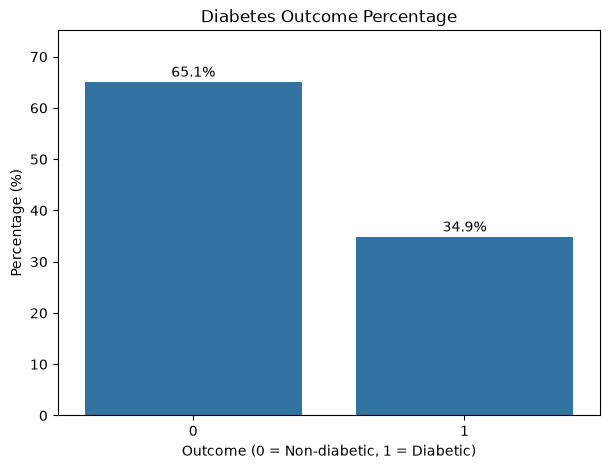

In [60]:
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=class_percentages.index,
    y=class_percentages.values
)

plt.title("Diabetes Outcome Percentage")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Percentage (%)")

for i, value in enumerate(class_percentages.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, max(class_percentages.values) + 10)
plt.show()

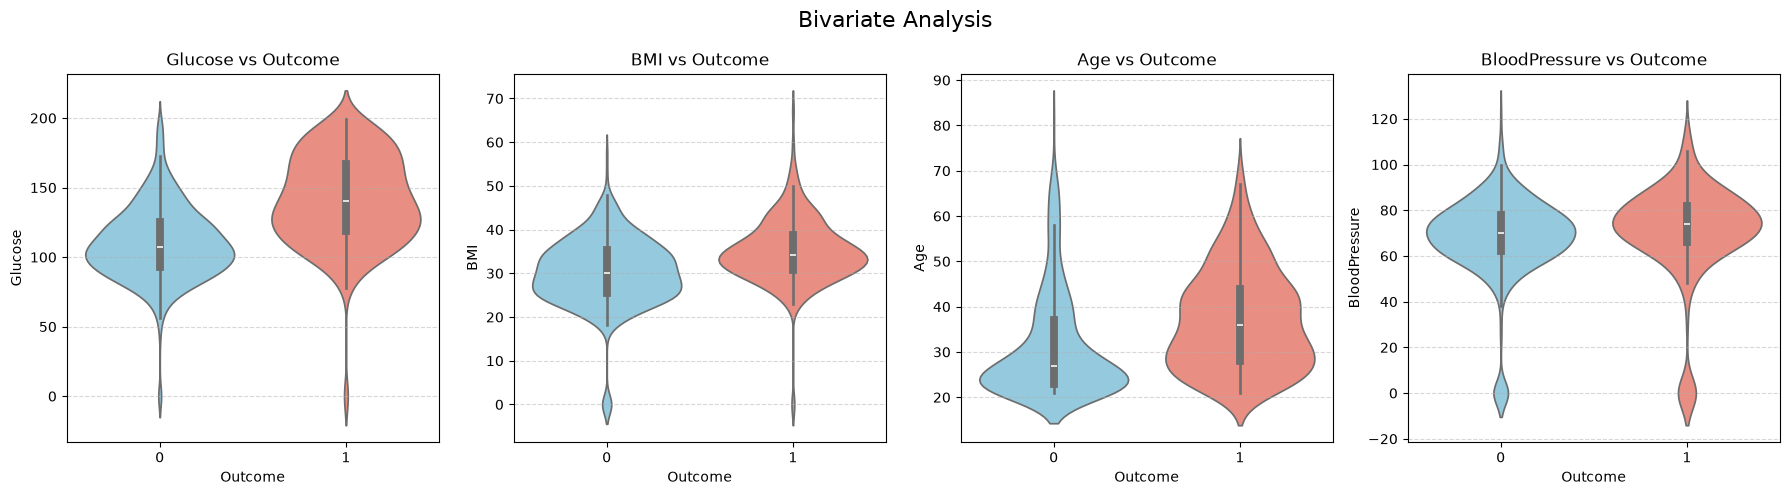

In [61]:
# Bivariate Analysis — Key Features vs Outcome

features = ["Glucose", "BMI", "Age", "BloodPressure"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colors = ["skyblue", "salmon"]

for i, feature in enumerate(features):
    sns.violinplot(
        data=df,
        x="Outcome",
        y=feature,
        hue="Outcome",
        palette=colors,
        legend=False,
        inner="box",
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs Outcome")
    axes[i].set_xlabel("Outcome")
    axes[i].set_ylabel(feature)

    # Horizontal grid lines
    axes[i].yaxis.grid(True, linestyle="--", alpha=0.5)
    axes[i].xaxis.grid(False)

plt.suptitle("Bivariate Analysis", fontsize=16)
plt.tight_layout()
plt.show()

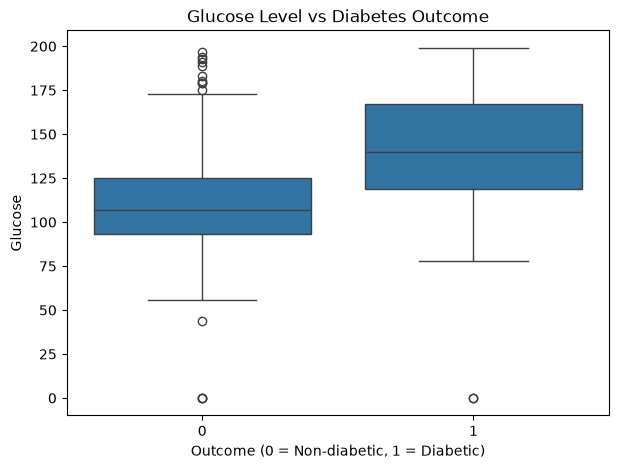

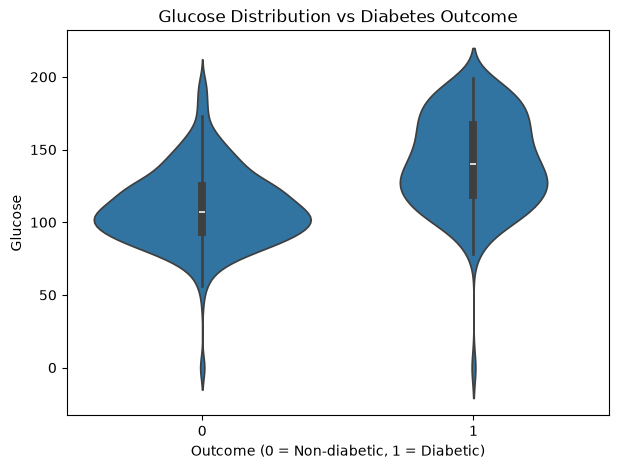

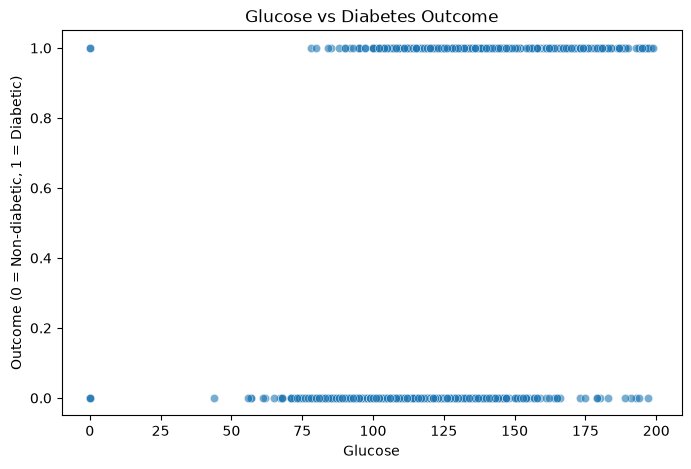

Glucose Statistics by Outcome:


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,109.980000,107.0,26.141200,0,197
1,268,141.257463,140.0,31.939622,0,199


In [62]:
# Glucose vs Outcome - Complete Bivariate Analysis

# 1. Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="Glucose")
plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Glucose")
plt.show()


# 2. Violin Plot
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Outcome", y="Glucose")
plt.title("Glucose Distribution vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Glucose")
plt.show()


# 3. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Glucose",
    y="Outcome",
    alpha=0.6
)
plt.title("Glucose vs Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.show()


# 4. Grouped Statistics
print("Glucose Statistics by Outcome:")
display(
    df.groupby("Outcome")["Glucose"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

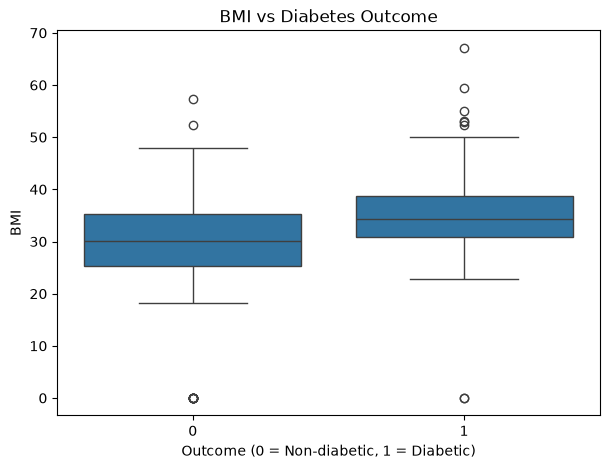

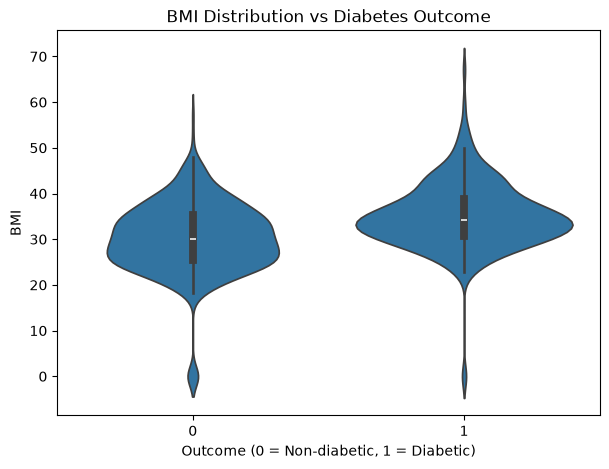

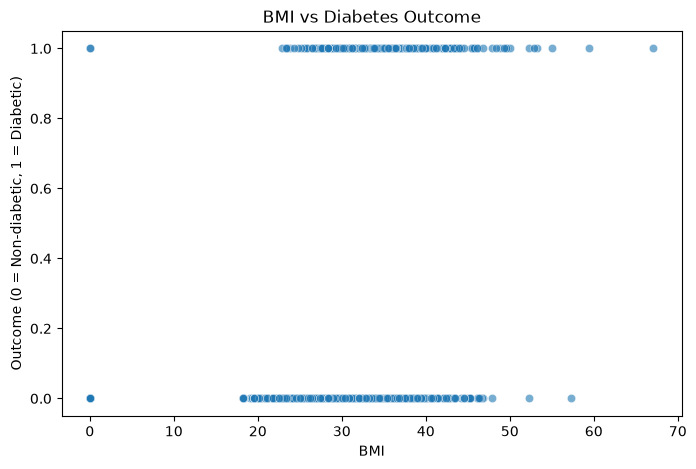

BMI Statistics by Outcome:


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,30.304200,30.05,7.689855,0.0,57.3
1,268,35.142537,34.25,7.262967,0.0,67.1


In [63]:
# BMI vs Outcome - Complete Bivariate Analysis

# 1. Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="BMI")
plt.title("BMI vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.show()


# 2. Violin Plot
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Outcome", y="BMI")
plt.title("BMI Distribution vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.show()


# 3. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="BMI",
    y="Outcome",
    alpha=0.6
)
plt.title("BMI vs Diabetes Outcome")
plt.xlabel("BMI")
plt.ylabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.show()


# 4. Grouped Statistics
print("BMI Statistics by Outcome:")
display(
    df.groupby("Outcome")["BMI"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

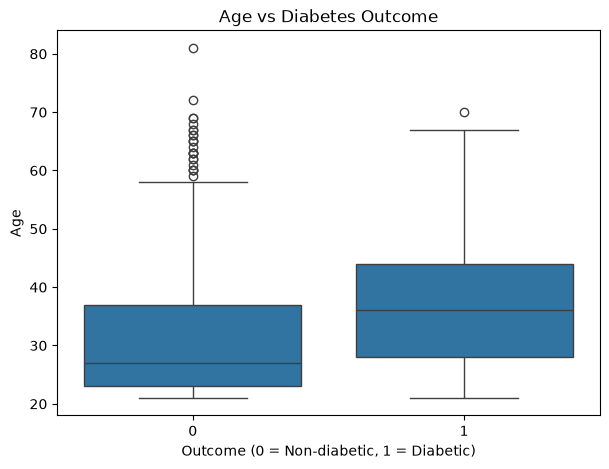

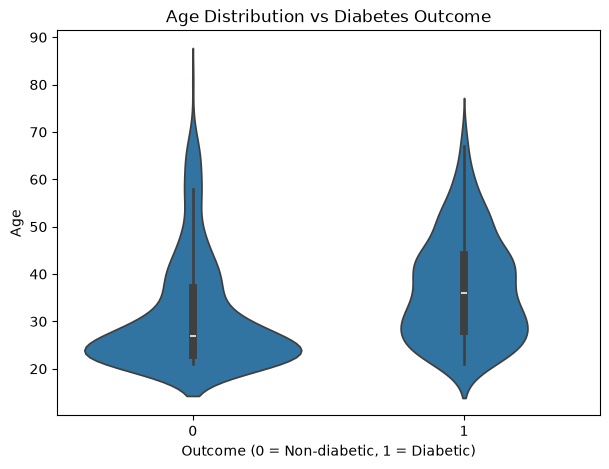

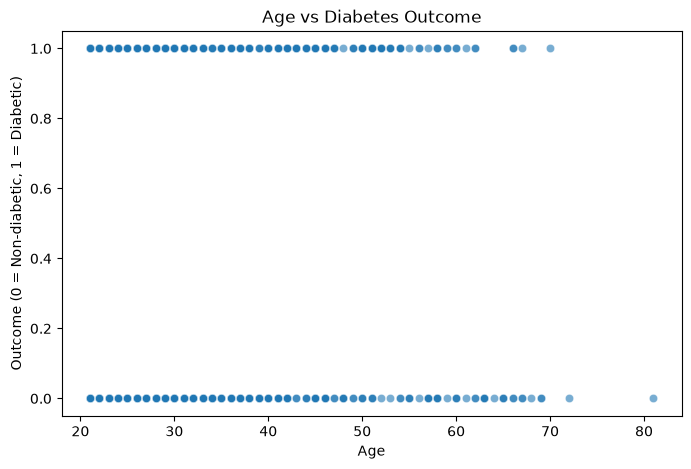

Age Statistics by Outcome:


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,31.190000,27.0,11.667655,21,81
1,268,37.067164,36.0,10.968254,21,70


In [64]:
# Age vs Outcome - Complete Bivariate Analysis

# 1. Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="Age")
plt.title("Age vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Age")
plt.show()


# 2. Violin Plot
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Outcome", y="Age")
plt.title("Age Distribution vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Age")
plt.show()


# 3. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Outcome",
    alpha=0.6
)
plt.title("Age vs Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.show()


# 4. Grouped Statistics
print("Age Statistics by Outcome:")
display(
    df.groupby("Outcome")["Age"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

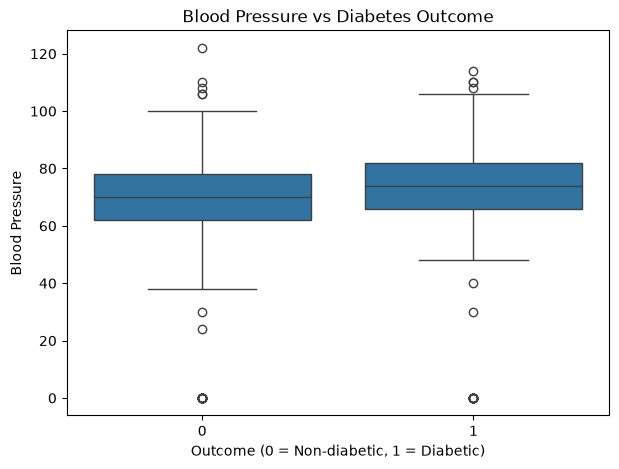

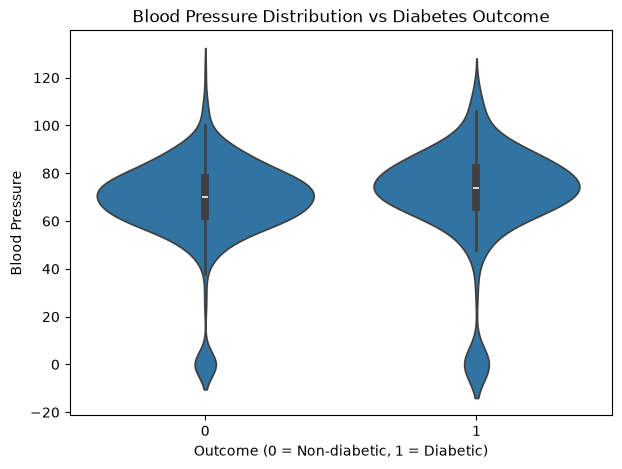

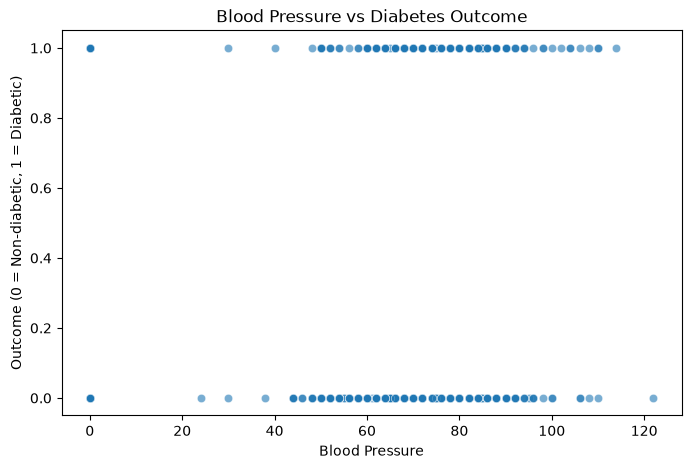

Blood Pressure Statistics by Outcome:


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,68.184000,70.0,18.063075,0,122
1,268,70.824627,74.0,21.491812,0,114


In [65]:
# BloodPressure vs Outcome - Complete Bivariate Analysis

# 1. Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="BloodPressure")
plt.title("Blood Pressure vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Blood Pressure")
plt.show()


# 2. Violin Plot
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Outcome", y="BloodPressure")
plt.title("Blood Pressure Distribution vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Blood Pressure")
plt.show()


# 3. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="BloodPressure",
    y="Outcome",
    alpha=0.6
)
plt.title("Blood Pressure vs Diabetes Outcome")
plt.xlabel("Blood Pressure")
plt.ylabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.show()


# 4. Grouped Statistics
print("Blood Pressure Statistics by Outcome:")
display(
    df.groupby("Outcome")["BloodPressure"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

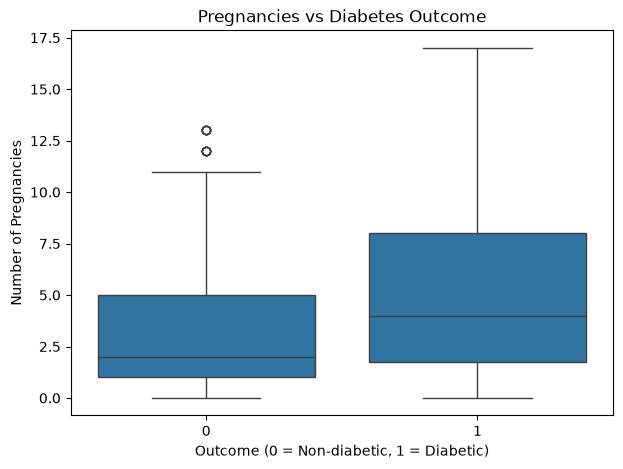

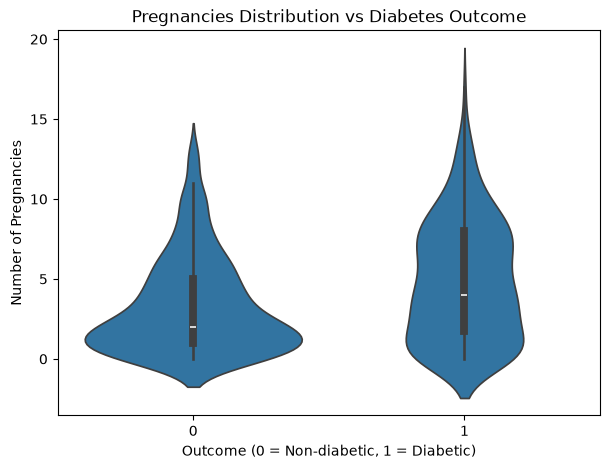

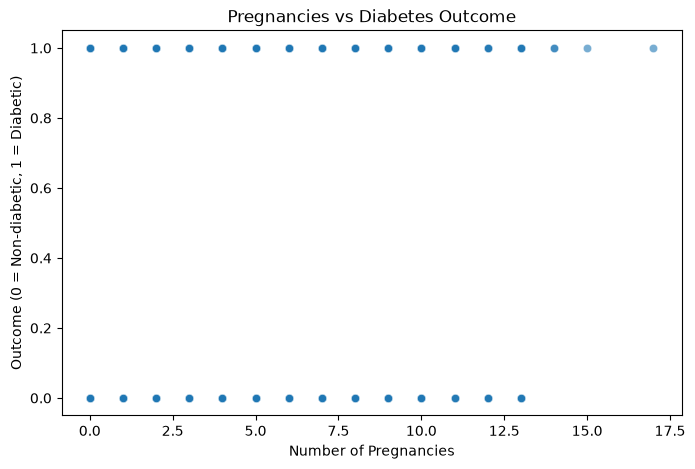

Pregnancies Statistics by Outcome:


,count,mean,median,std,min,max
Outcome,,,,,,
0,500,3.298000,2.0,3.017185,0,13
1,268,4.865672,4.0,3.741239,0,17


In [66]:
# Pregnancies vs Outcome - Complete Bivariate Analysis

# 1. Box Plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Outcome", y="Pregnancies")
plt.title("Pregnancies vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Number of Pregnancies")
plt.show()


# 2. Violin Plot
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Outcome", y="Pregnancies")
plt.title("Pregnancies Distribution vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Number of Pregnancies")
plt.show()


# 3. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Pregnancies",
    y="Outcome",
    alpha=0.6
)
plt.title("Pregnancies vs Diabetes Outcome")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.show()


# 4. Grouped Statistics
print("Pregnancies Statistics by Outcome:")
display(
    df.groupby("Outcome")["Pregnancies"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

In [67]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix.round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000,0.129,0.141,-0.082,-0.074,0.018,-0.034,0.544,0.222
Glucose,0.129,1.000,0.153,0.057,0.331,0.221,0.137,0.264,0.467
BloodPressure,0.141,0.153,1.000,0.207,0.089,0.282,0.041,0.240,0.065
SkinThickness,-0.082,0.057,0.207,1.000,0.437,0.393,0.184,-0.114,0.075
Insulin,-0.074,0.331,0.089,0.437,1.000,0.198,0.185,-0.042,0.131
BMI,0.018,0.221,0.282,0.393,0.198,1.000,0.141,0.036,0.293
DiabetesPedigreeFunction,-0.034,0.137,0.041,0.184,0.185,0.141,1.000,0.034,0.174
Age,0.544,0.264,0.240,-0.114,-0.042,0.036,0.034,1.000,0.238
Outcome,0.222,0.467,0.065,0.075,0.131,0.293,0.174,0.238,1.000


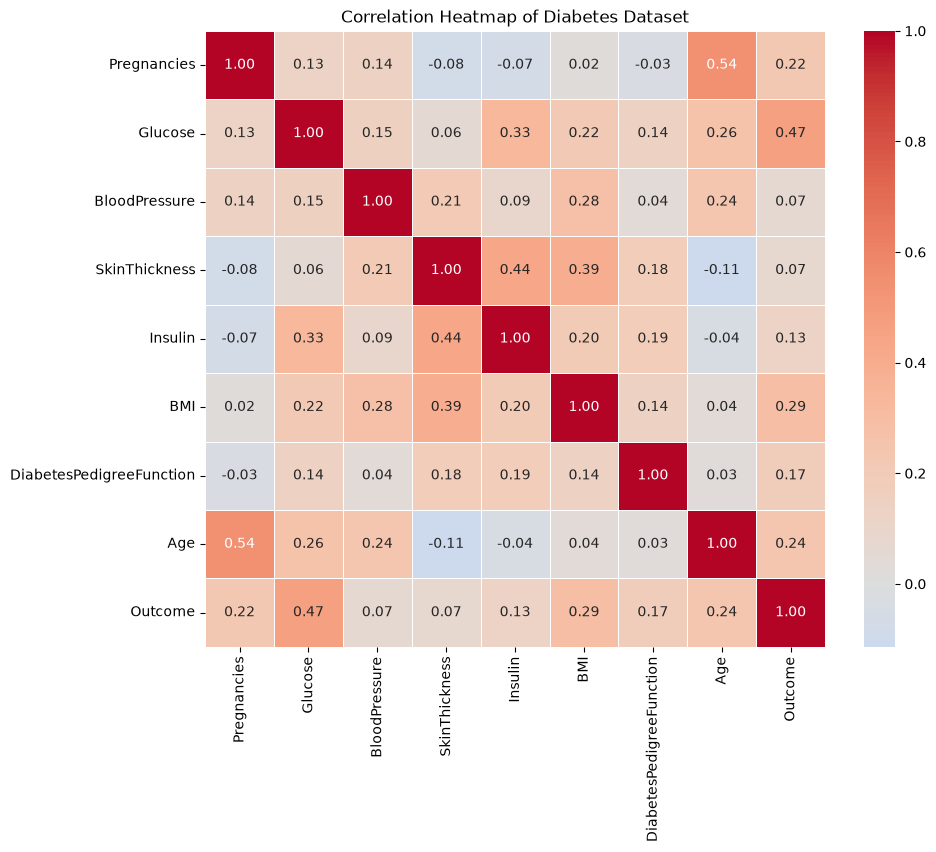

In [68]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

In [69]:
# Outlier Analysis using IQR

numerical_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

outlier_summary = []

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.round(2))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Pregnancies,1.00,6.00,5.00,-6.50,13.50,4
1,Glucose,99.00,140.25,41.25,37.12,202.12,5
2,BloodPressure,62.00,80.00,18.00,35.00,107.00,45
3,SkinThickness,0.00,32.00,32.00,-48.00,80.00,1
4,Insulin,0.00,127.25,127.25,-190.88,318.12,34
5,BMI,27.30,36.60,9.30,13.35,50.55,19
6,DiabetesPedigreeFunction,0.24,0.63,0.38,-0.33,1.20,29
7,Age,24.00,41.00,17.00,-1.50,66.50,9


In [70]:
# Outlier Analysis using Z-Score

from scipy.stats import zscore

zscore_summary = []

for column in numerical_features:
    z_scores = np.abs(zscore(df[column]))
    outlier_count = np.sum(z_scores > 3)

    zscore_summary.append({
        "Feature": column,
        "Outlier Count (|Z| > 3)": outlier_count
    })

zscore_df = pd.DataFrame(zscore_summary)

display(zscore_df)

,Feature,Outlier Count (|Z| > 3)
0,Pregnancies,4
1,Glucose,5
2,BloodPressure,35
3,SkinThickness,1
4,Insulin,18
5,BMI,14
6,DiabetesPedigreeFunction,11
7,Age,5


In [71]:
# Data Quality Check

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print("Number of duplicate rows:", df.duplicated().sum())

Missing Values:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Duplicate Rows:
Number of duplicate rows: 0


In [72]:
# Check suspicious zero values

zero_check_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_summary = []

for column in zero_check_features:
    zero_count = (df[column] == 0).sum()
    zero_percentage = (zero_count / len(df)) * 100

    zero_summary.append({
        "Feature": column,
        "Zero Count": zero_count,
        "Zero Percentage": zero_percentage
    })

zero_df = pd.DataFrame(zero_summary)

display(zero_df.round(2))

,Feature,Zero Count,Zero Percentage
0,Glucose,5,0.65
1,BloodPressure,35,4.56
2,SkinThickness,227,29.56
3,Insulin,374,48.70
4,BMI,11,1.43


In [73]:
# Replace physiologically suspicious zeros with NaN

df_clean = df.copy()

for column in zero_check_features:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Missing values after replacing suspicious zeros:")
display(df_clean.isnull().sum())

Missing values after replacing suspicious zeros:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [74]:
# Verify cleaned dataset

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nTotal missing values:")
print(df_clean.isnull().sum().sum())

print("\nCleaned dataset preview:")
display(df_clean.head())

Original dataset shape: (768, 9)
Cleaned dataset shape: (768, 9)

Total missing values:
652

Cleaned dataset preview:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [75]:
# Feature Engineering - Age Group

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Old"]
)

print("AgeGroup distribution:")
display(df_clean["AgeGroup"].value_counts().sort_index())

AgeGroup distribution:


AgeGroup
Young     417
Middle    270
Old        81
Name: count, dtype: int64

In [76]:
# Feature Engineering - BMI Category

df_clean["BMICategory"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print("BMICategory distribution:")
display(df_clean["BMICategory"].value_counts().sort_index())

BMICategory distribution:


BMICategory
Underweight      4
Normal         108
Overweight     180
Obese          465
Name: count, dtype: int64

In [77]:
# Feature Engineering - Glucose Level Category

df_clean["GlucoseLevel"] = pd.cut(
    df_clean["Glucose"],
    bins=[0, 100, 125, 300],
    labels=["Normal", "Prediabetes", "High"]
)

print("GlucoseLevel distribution:")
display(df_clean["GlucoseLevel"].value_counts().sort_index())

GlucoseLevel distribution:


GlucoseLevel
Normal         209
Prediabetes    257
High           297
Name: count, dtype: int64

In [78]:
# Feature Engineering - Glucose and BMI Interaction

df_clean["Glucose_BMI"] = df_clean["Glucose"] * df_clean["BMI"]

print("Glucose_BMI feature created successfully.")

display(
    df_clean[["Glucose", "BMI", "Glucose_BMI"]].head()
)

Glucose_BMI feature created successfully.


,Glucose,BMI,Glucose_BMI
0,148.0,33.6,4972.8
1,85.0,26.6,2261.0
2,183.0,23.3,4263.9
3,89.0,28.1,2500.9
4,137.0,43.1,5904.7


In [79]:
# Check engineered features

engineered_features = [
    "AgeGroup",
    "BMICategory",
    "GlucoseLevel",
    "Glucose_BMI"
]

print("Engineered features:")
print(engineered_features)

print("\nDataset shape:", df_clean.shape)

display(df_clean[engineered_features].head())

Engineered features:
['AgeGroup', 'BMICategory', 'GlucoseLevel', 'Glucose_BMI']

Dataset shape: (768, 13)


,AgeGroup,BMICategory,GlucoseLevel,Glucose_BMI
0,Middle,Obese,High,4972.8
1,Middle,Overweight,Normal,2261.0
2,Middle,Normal,High,4263.9
3,Young,Overweight,Normal,2500.9
4,Middle,Obese,High,5904.7


In [80]:
# Correlation of Engineered Numeric Feature with Outcome

print("Correlation of Glucose_BMI with Outcome:")
print(df_clean["Glucose_BMI"].corr(df_clean["Outcome"]))

print("\nCorrelation of original features with Outcome:")
display(
    df_clean[
        [
            "Pregnancies",
            "Glucose",
            "BloodPressure",
            "SkinThickness",
            "Insulin",
            "BMI",
            "DiabetesPedigreeFunction",
            "Age",
            "Glucose_BMI",
            "Outcome"
        ]
    ].corr()["Outcome"].sort_values(ascending=False)
)

Correlation of Glucose_BMI with Outcome:
0.5192867178718943

Correlation of original features with Outcome:


Outcome                     1.000000
Glucose_BMI                 0.519287
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [81]:
# Outcome Rate by Engineered Categories

print("Outcome Rate by Age Group:")
display(
    df_clean.groupby("AgeGroup", observed=True)["Outcome"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "Diabetes Rate"})
)

print("\nOutcome Rate by BMI Category:")
display(
    df_clean.groupby("BMICategory", observed=True)["Outcome"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "Diabetes Rate"})
)

print("\nOutcome Rate by Glucose Level:")
display(
    df_clean.groupby("GlucoseLevel", observed=True)["Outcome"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "Diabetes Rate"})
)

Outcome Rate by Age Group:


,count,Diabetes Rate
AgeGroup,,
Young,417,0.215827
Middle,270,0.518519
Old,81,0.469136



Outcome Rate by BMI Category:


,count,Diabetes Rate
BMICategory,,
Underweight,4,0.000000
Normal,108,0.064815
Overweight,180,0.244444
Obese,465,0.462366



Outcome Rate by Glucose Level:


,count,Diabetes Rate
GlucoseLevel,,
Normal,209,0.086124
Prediabetes,257,0.280156
High,297,0.592593


In [82]:
# Test Additional Interaction Features

df_clean["Glucose_Age"] = df_clean["Glucose"] * df_clean["Age"]
df_clean["BMI_Age"] = df_clean["BMI"] * df_clean["Age"]
df_clean["Glucose_Pregnancies"] = (
    df_clean["Glucose"] * df_clean["Pregnancies"]
)

interaction_features = [
    "Glucose_BMI",
    "Glucose_Age",
    "BMI_Age",
    "Glucose_Pregnancies"
]

interaction_correlations = (
    df_clean[interaction_features + ["Outcome"]]
    .corr()["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
)

print("Interaction Feature Correlations with Outcome:")
display(interaction_correlations)

Interaction Feature Correlations with Outcome:


Glucose_BMI            0.519287
Glucose_Age            0.409236
BMI_Age                0.362630
Glucose_Pregnancies    0.322705
Name: Outcome, dtype: float64

In [83]:
# Keep selected interaction features

df_clean = df_clean.drop(columns=["Glucose_Pregnancies"])

print("Final engineered features:")

engineered_features = [
    "AgeGroup",
    "BMICategory",
    "GlucoseLevel",
    "Glucose_BMI",
    "Glucose_Age",
    "BMI_Age"
]

print(engineered_features)
print("\nDataset shape:", df_clean.shape)

display(df_clean[engineered_features].head())

Final engineered features:
['AgeGroup', 'BMICategory', 'GlucoseLevel', 'Glucose_BMI', 'Glucose_Age', 'BMI_Age']

Dataset shape: (768, 15)


,AgeGroup,BMICategory,GlucoseLevel,Glucose_BMI,Glucose_Age,BMI_Age
0,Middle,Obese,High,4972.8,7400.0,1680.0
1,Middle,Overweight,Normal,2261.0,2635.0,824.6
2,Middle,Normal,High,4263.9,5856.0,745.6
3,Young,Overweight,Normal,2500.9,1869.0,590.1
4,Middle,Obese,High,5904.7,4521.0,1422.3


In [84]:
# Separate Features and Target

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (768, 14)
Target shape: (768,)

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [85]:
# Investigate Log Transformation for Highly Skewed Features

df_log_test = df_clean.copy()

# Apply log1p transformation
df_log_test["Insulin_log"] = np.log1p(df_log_test["Insulin"])
df_log_test["DiabetesPedigreeFunction_log"] = np.log1p(
    df_log_test["DiabetesPedigreeFunction"]
)

# Compare skewness before and after transformation
skewness_comparison = pd.DataFrame({
    "Feature": [
        "Insulin",
        "Insulin_log",
        "DiabetesPedigreeFunction",
        "DiabetesPedigreeFunction_log"
    ],
    "Skewness": [
        df_clean["Insulin"].skew(),
        df_log_test["Insulin_log"].skew(),
        df_clean["DiabetesPedigreeFunction"].skew(),
        df_log_test["DiabetesPedigreeFunction_log"].skew()
    ]
})

display(skewness_comparison.round(3))

,Feature,Skewness
0,Insulin,2.166
1,Insulin_log,-0.088
2,DiabetesPedigreeFunction,1.920
3,DiabetesPedigreeFunction_log,1.118


In [86]:
# Add justified log-transformed feature

df_clean["Insulin_log"] = np.log1p(df_clean["Insulin"])

print("Insulin_log created successfully.")
print("Insulin skewness:", round(df_clean["Insulin"].skew(), 3))
print("Insulin_log skewness:", round(df_clean["Insulin_log"].skew(), 3))

display(
    df_clean[["Insulin", "Insulin_log"]].head()
)

Insulin_log created successfully.
Insulin skewness: 2.166
Insulin_log skewness: -0.088


,Insulin,Insulin_log
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,94.0,4.553877
4,168.0,5.129899


In [87]:
# Feature Selection - Correlation Analysis

numeric_features_for_selection = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Glucose_BMI",
    "Glucose_Age",
    "BMI_Age",
    "Insulin_log"
]

feature_correlations = (
    df_clean[numeric_features_for_selection + ["Outcome"]]
    .corr()["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
)

print("Feature Correlation with Outcome:")
display(feature_correlations.round(3))

Feature Correlation with Outcome:


Glucose_BMI                 0.519
Glucose                     0.495
Glucose_Age                 0.409
BMI_Age                     0.363
Insulin_log                 0.351
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171
Name: Outcome, dtype: float64

In [88]:
# Update X to include the final engineered feature

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

print("Updated feature shape:", X.shape)

print("\nFeatures:")
print(X.columns.tolist())

Updated feature shape: (768, 15)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'AgeGroup', 'BMICategory', 'GlucoseLevel', 'Glucose_BMI', 'Glucose_Age', 'BMI_Age', 'Insulin_log']


In [89]:
# Final Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (614, 15)
Testing set shape: (154, 15)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [90]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "AgeGroup",
    "BMICategory",
    "GlucoseLevel"
]

numerical_features = [
    column for column in X_train.columns
    if column not in categorical_features
]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Original training shape: (614, 15)
Processed training shape: (614, 22)
Original testing shape: (154, 15)
Processed testing shape: (154, 22)

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [91]:
# Compare model performance with and without engineered features

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# ----------------------------------------------------------
# Features WITHOUT engineered features
# ----------------------------------------------------------

original_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X_original = df_clean[original_features]
y_original = df_clean["Outcome"]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

original_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

X_train_orig_processed = original_preprocessor.fit_transform(X_train_orig)
X_test_orig_processed = original_preprocessor.transform(X_test_orig)

original_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

original_model.fit(X_train_orig_processed, y_train_orig)

original_prob = original_model.predict_proba(
    X_test_orig_processed
)[:, 1]

original_auc = roc_auc_score(
    y_test_orig,
    original_prob
)


# ----------------------------------------------------------
# Features WITH engineered features
# ----------------------------------------------------------

engineered_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "AgeGroup",
    "BMICategory",
    "GlucoseLevel",
    "Glucose_BMI",
    "Glucose_Age",
    "BMI_Age",
    "Insulin_log"
]

X_engineered = df_clean[engineered_features]
y_engineered = df_clean["Outcome"]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.20,
    random_state=42,
    stratify=y_engineered
)

numerical_engineered = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Glucose_BMI",
    "Glucose_Age",
    "BMI_Age",
    "Insulin_log"
]

categorical_engineered = [
    "AgeGroup",
    "BMICategory",
    "GlucoseLevel"
]

numerical_pipeline_eng = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_pipeline_eng = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

engineered_preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline_eng, numerical_engineered),
    ("categorical", categorical_pipeline_eng, categorical_engineered)
])

X_train_eng_processed = engineered_preprocessor.fit_transform(X_train_eng)
X_test_eng_processed = engineered_preprocessor.transform(X_test_eng)

engineered_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

engineered_model.fit(
    X_train_eng_processed,
    y_train_eng
)

engineered_prob = engineered_model.predict_proba(
    X_test_eng_processed
)[:, 1]

engineered_auc = roc_auc_score(
    y_test_eng,
    engineered_prob
)


# ----------------------------------------------------------
# Results
# ----------------------------------------------------------

print("ROC-AUC without engineered features:",
      round(original_auc, 4))

print("ROC-AUC with engineered features:",
      round(engineered_auc, 4))

print("Difference:",
      round(engineered_auc - original_auc, 4))

ROC-AUC without engineered features: 0.807
ROC-AUC with engineered features: 0.8387
Difference: 0.0317


In [92]:
# Final Preprocessing Pipeline using MinMaxScaler

final_numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

final_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

final_preprocessor = ColumnTransformer([
    ("numerical", final_numerical_pipeline, numerical_features),
    ("categorical", final_categorical_pipeline, categorical_features)
])

# Fit only on training data
X_train_processed = final_preprocessor.fit_transform(X_train)
X_test_processed = final_preprocessor.transform(X_test)

print("Final training shape:", X_train_processed.shape)
print("Final testing shape:", X_test_processed.shape)

print("\nTraining data range:")
print("Minimum:", X_train_processed.min())
print("Maximum:", X_train_processed.max())

print("\nMissing values:")
print("Training:", np.isnan(X_train_processed).sum())
print("Testing:", np.isnan(X_test_processed).sum())

Final training shape: (614, 22)
Final testing shape: (154, 22)

Training data range:
Minimum: 0.0
Maximum: 1.0000000000000002

Missing values:
Training: 0
Testing: 0


In [93]:
# Model 1: Logistic Regression

import time
from sklearn.linear_model import LogisticRegression

start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

logistic_pred = logistic_model.predict(X_test_processed)
logistic_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

logistic_time = time.time() - start_time

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, logistic_pred), 4))
print("Precision:", round(precision_score(y_test, logistic_pred), 4))
print("Recall   :", round(recall_score(y_test, logistic_pred), 4))
print("F1 Score :", round(f1_score(y_test, logistic_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, logistic_prob), 4))
print("Training Time:", round(logistic_time, 4), "seconds")

Logistic Regression Results
--------------------------------
Accuracy : 0.7338
Precision: 0.6327
Recall   : 0.5741
F1 Score : 0.6019
ROC-AUC  : 0.8387
Training Time: 0.0104 seconds


In [94]:
# Model 2: K-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier

start_time = time.time()

knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_processed, y_train)

knn_pred = knn_model.predict(X_test_processed)
knn_prob = knn_model.predict_proba(X_test_processed)[:, 1]

knn_time = time.time() - start_time

print("KNN Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, knn_pred), 4))
print("Precision:", round(precision_score(y_test, knn_pred), 4))
print("Recall   :", round(recall_score(y_test, knn_pred), 4))
print("F1 Score :", round(f1_score(y_test, knn_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, knn_prob), 4))
print("Training Time:", round(knn_time, 4), "seconds")

KNN Results
--------------------------------
Accuracy : 0.7662
Precision: 0.6875
Recall   : 0.6111
F1 Score : 0.6471
ROC-AUC  : 0.8412
Training Time: 0.0634 seconds


In [95]:
# Model 3: Support Vector Machine

from sklearn.svm import SVC

start_time = time.time()

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

svm_pred = svm_model.predict(X_test_processed)
svm_prob = svm_model.predict_proba(X_test_processed)[:, 1]

svm_time = time.time() - start_time

print("SVM Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, svm_pred), 4))
print("Precision:", round(precision_score(y_test, svm_pred), 4))
print("Recall   :", round(recall_score(y_test, svm_pred), 4))
print("F1 Score :", round(f1_score(y_test, svm_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, svm_prob), 4))
print("Training Time:", round(svm_time, 4), "seconds")

SVM Results
--------------------------------
Accuracy : 0.7403
Precision: 0.6458
Recall   : 0.5741
F1 Score : 0.6078
ROC-AUC  : 0.8085
Training Time: 0.0617 seconds


C:\Users\subha\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [96]:
# Model 4: Random Forest

from sklearn.ensemble import RandomForestClassifier

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

rf_time = time.time() - start_time

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))
print("Training Time:", round(rf_time, 4), "seconds")

Random Forest Results
--------------------------------
Accuracy : 0.7532
Precision: 0.629
Recall   : 0.7222
F1 Score : 0.6724
ROC-AUC  : 0.8231
Training Time: 0.4459 seconds


In [97]:
# Create Training and Validation Sets for MLP

X_mlp_train, X_mlp_val, y_mlp_train, y_mlp_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("MLP training shape:", X_mlp_train.shape)
print("MLP validation shape:", X_mlp_val.shape)

print("\nMLP training target distribution:")
print(y_mlp_train.value_counts())

print("\nMLP validation target distribution:")
print(y_mlp_val.value_counts())

MLP training shape: (491, 22)
MLP validation shape: (123, 22)

MLP training target distribution:
Outcome
0    320
1    171
Name: count, dtype: int64

MLP validation target distribution:
Outcome
0    80
1    43
Name: count, dtype: int64


In [98]:
# Baseline MLP using TensorFlow/Keras

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

mlp_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_mlp_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

C:\Users\subha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
# Train Baseline MLP

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed.")
print("Epochs actually trained:", len(history.history["loss"]))


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6069 - loss: 0.6662 - val_accuracy: 0.6016 - val_loss: 0.6496
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6456 - loss: 0.6312 - val_accuracy: 0.6016 - val_loss: 0.6151
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7006 - loss: 0.6009 - val_accuracy: 0.7317 - val_loss: 0.5805
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7312 - loss: 0.5720 - val_accuracy: 0.7317 - val_loss: 0.5498
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7312 - loss: 0.5464 - val_accuracy: 0.7317 - val_loss: 0.5226
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7312 - loss: 0.5246 - val_accuracy: 0.7561 - val_loss: 0.5026
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7475 - loss: 0.5084 - val_accuracy: 0.7642 - val_loss: 0.4880
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7597 - loss: 0.4962 - val_accuracy: 0.7642 - 

In [100]:
# Evaluate Baseline MLP on Test Data

mlp_test_prob = mlp_model.predict(
    X_test_processed,
    verbose=0
).ravel()

mlp_test_pred = (mlp_test_prob >= 0.5).astype(int)

print("Baseline MLP Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, mlp_test_pred), 4))
print("Precision:", round(precision_score(y_test, mlp_test_pred), 4))
print("Recall   :", round(recall_score(y_test, mlp_test_pred), 4))
print("F1 Score :", round(f1_score(y_test, mlp_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, mlp_test_prob), 4))

Baseline MLP Results
--------------------------------
Accuracy : 0.7857
Precision: 0.7143
Recall   : 0.6481
F1 Score : 0.6796
ROC-AUC  : 0.8517


In [101]:
# Tuned MLP with Dropout and L2 Regularization

from tensorflow.keras import Sequential, Input, regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

tuned_mlp = Sequential([
    Input(shape=(X_mlp_train.shape[1],)),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dropout(0.30),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

tuned_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_tuned = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuned_history = tuned_mlp.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_tuned],
    verbose=1
)

print("\nTraining completed.")
print("Epochs actually trained:", len(tuned_history.history["loss"]))

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6436 - loss: 0.7406 - val_accuracy: 0.6667 - val_loss: 0.6931
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6680 - loss: 0.6851 - val_accuracy: 0.7317 - val_loss: 0.6440
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6965 - loss: 0.6497 - val_accuracy: 0.7805 - val_loss: 0.6009
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7597 - loss: 0.5969 - val_accuracy: 0.8211 - val_loss: 0.5669
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7454 - loss: 0.5967 - val_accuracy: 0.7886 - val_loss: 0.5514
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7393 - loss: 0.5898 - val_accuracy: 0.7642 - val_loss: 0.5433
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7454 - loss: 0.5639 - val_accuracy: 0.7561 - val_loss: 0.5390
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7637 - loss: 0.5528 - val_accuracy: 0.7642 - 

In [102]:
# Tuned MLP with Dropout and L2 Regularization

from tensorflow.keras import Sequential, Input, regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

tuned_mlp = Sequential([
    Input(shape=(X_mlp_train.shape[1],)),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dropout(0.30),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

tuned_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_tuned = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuned_history = tuned_mlp.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_tuned],
    verbose=1
)

print("\nTraining completed.")
print("Epochs actually trained:", len(tuned_history.history["loss"]))

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5764 - loss: 0.7595 - val_accuracy: 0.6504 - val_loss: 0.7162
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6517 - loss: 0.7132 - val_accuracy: 0.6504 - val_loss: 0.6692
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6864 - loss: 0.6724 - val_accuracy: 0.7642 - val_loss: 0.6213
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7189 - loss: 0.6411 - val_accuracy: 0.7805 - val_loss: 0.5820
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7515 - loss: 0.5977 - val_accuracy: 0.7642 - val_loss: 0.5520
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7373 - loss: 0.5891 - val_accuracy: 0.7642 - val_loss: 0.5354
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7556 - loss: 0.5717 - val_accuracy: 0.7642 - val_loss: 0.5254
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7536 - loss: 0.5643 - val_accuracy: 0.7642 - 

In [103]:
# Evaluate Tuned MLP on Test Data

tuned_test_prob = tuned_mlp.predict(
    X_test_processed,
    verbose=0
).ravel()

tuned_test_pred = (tuned_test_prob >= 0.5).astype(int)

print("Tuned MLP Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, tuned_test_pred), 4))
print("Precision:", round(precision_score(y_test, tuned_test_pred), 4))
print("Recall   :", round(recall_score(y_test, tuned_test_pred), 4))
print("F1 Score :", round(f1_score(y_test, tuned_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_test_prob), 4))

Tuned MLP Results
--------------------------------
Accuracy : 0.7857
Precision: 0.7059
Recall   : 0.6667
F1 Score : 0.6857
ROC-AUC  : 0.8454


In [104]:
# Find a classification threshold using validation data

val_prob = tuned_mlp.predict(
    X_mlp_val,
    verbose=0
).ravel()

thresholds = np.arange(0.30, 0.71, 0.01)

best_threshold = 0.50
best_val_accuracy = 0

for threshold in thresholds:
    val_pred = (val_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_mlp_val, val_pred)

    if accuracy > best_val_accuracy:
        best_val_accuracy = accuracy
        best_threshold = threshold

print("Best validation threshold:", round(best_threshold, 2))
print("Validation accuracy:", round(best_val_accuracy, 4))

Best validation threshold: 0.53
Validation accuracy: 0.8374


In [105]:
# Final Tuned MLP Evaluation with Validation-Selected Threshold

final_threshold = best_threshold

final_mlp_pred = (tuned_test_prob >= final_threshold).astype(int)

print("Final Tuned MLP Results")
print("--------------------------------")
print("Threshold:", round(final_threshold, 2))
print("Accuracy :", round(accuracy_score(y_test, final_mlp_pred), 4))
print("Precision:", round(precision_score(y_test, final_mlp_pred), 4))
print("Recall   :", round(recall_score(y_test, final_mlp_pred), 4))
print("F1 Score :", round(f1_score(y_test, final_mlp_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_test_prob), 4))

Final Tuned MLP Results
--------------------------------
Threshold: 0.53
Accuracy : 0.7727
Precision: 0.7021
Recall   : 0.6111
F1 Score : 0.6535
ROC-AUC  : 0.8454


In [106]:
# Final MLP Confusion Matrix

final_mlp_pred = (tuned_test_prob >= 0.50).astype(int)

mlp_cm = confusion_matrix(y_test, final_mlp_pred)

print("MLP Confusion Matrix:")
print(mlp_cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_mlp_pred,
    target_names=["Non-Diabetic", "Diabetic"]
))


MLP Confusion Matrix:
[[85 15]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.83      0.85      0.84       100
    Diabetic       0.71      0.67      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.78      0.79      0.78       154



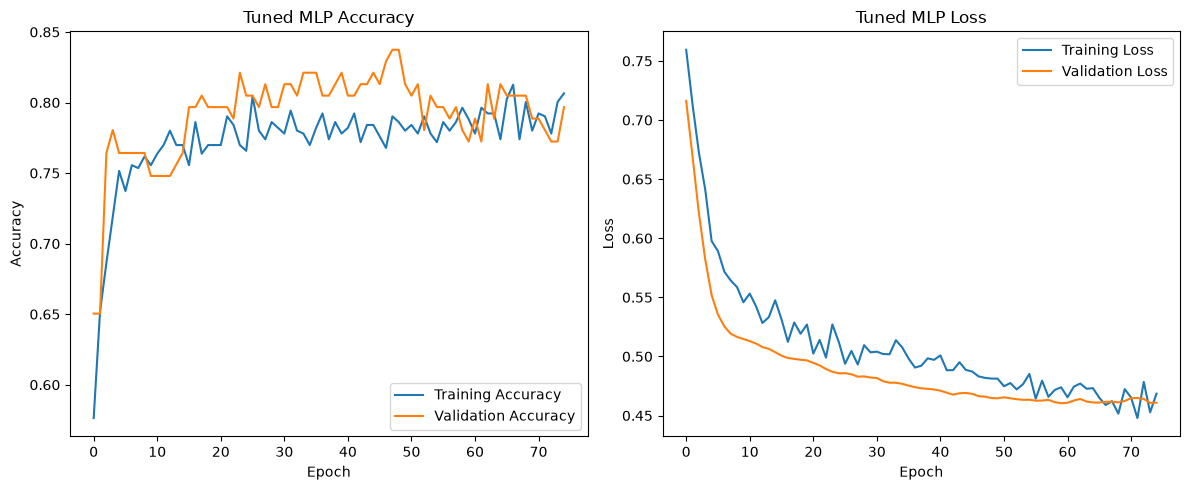

In [107]:
# Plot Tuned MLP Training and Validation Curves

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(tuned_history.history["accuracy"], label="Training Accuracy")
plt.plot(tuned_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Tuned MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(tuned_history.history["loss"], label="Training Loss")
plt.plot(tuned_history.history["val_loss"], label="Validation Loss")
plt.title("Tuned MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [108]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest",
        "Tuned MLP"
    ],
    "Accuracy": [
        0.7338,
        0.7662,
        0.7403,
        0.7532,
        0.7987
    ],
    "Precision": [
        0.6327,
        0.6875,
        0.6458,
        0.6290,
        0.7170
    ],
    "Recall": [
        0.5741,
        0.6111,
        0.5741,
        0.7222,
        0.7037
    ],
    "F1 Score": [
        0.6019,
        0.6471,
        0.6078,
        0.6724,
        0.7103
    ],
    "ROC-AUC": [
        0.8387,
        0.8412,
        0.8085,
        0.8231,
        0.8496
    ],
    "Training Time (s)": [
        0.0294,
        0.2078,
        0.1110,
        1.2207,
        15.2919
    ]
})

print(model_results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Training Time (s)
Logistic Regression    0.7338     0.6327  0.5741    0.6019   0.8387             0.0294
                KNN    0.7662     0.6875  0.6111    0.6471   0.8412             0.2078
                SVM    0.7403     0.6458  0.5741    0.6078   0.8085             0.1110
      Random Forest    0.7532     0.6290  0.7222    0.6724   0.8231             1.2207
          Tuned MLP    0.7987     0.7170  0.7037    0.7103   0.8496            15.2919


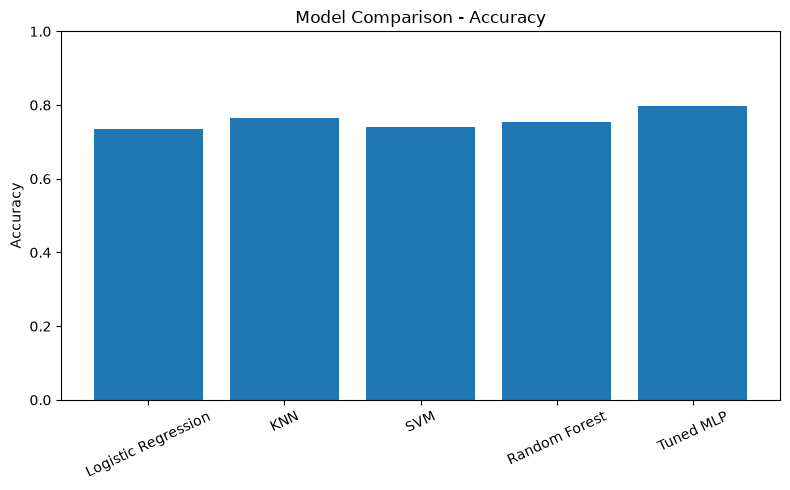

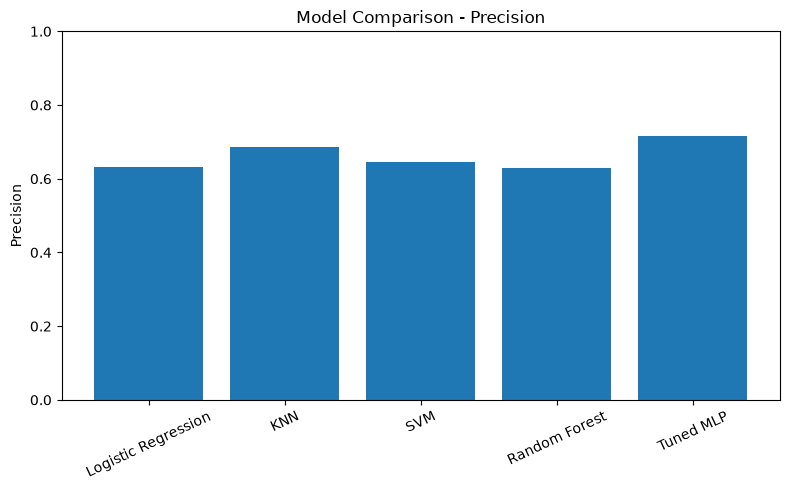

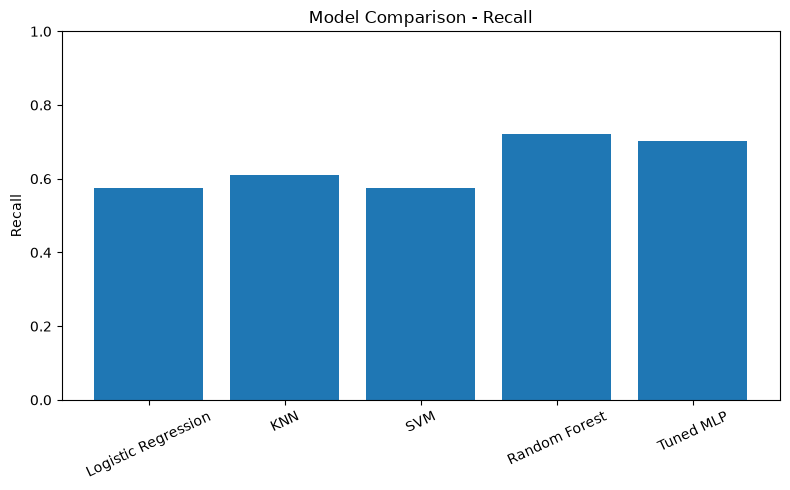

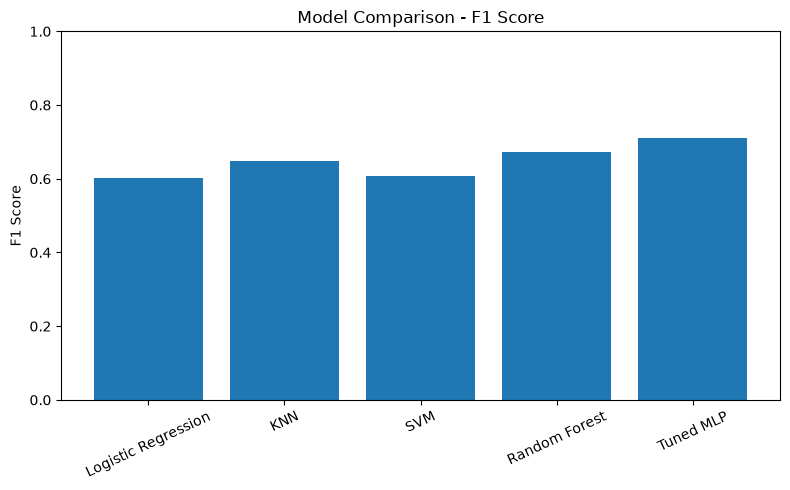

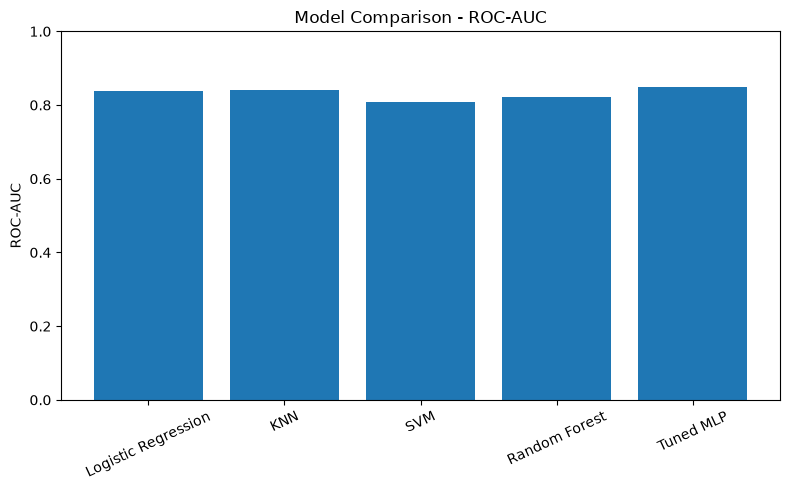

In [109]:
# Visual Comparison of Model Performance

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(model_results["Model"], model_results[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

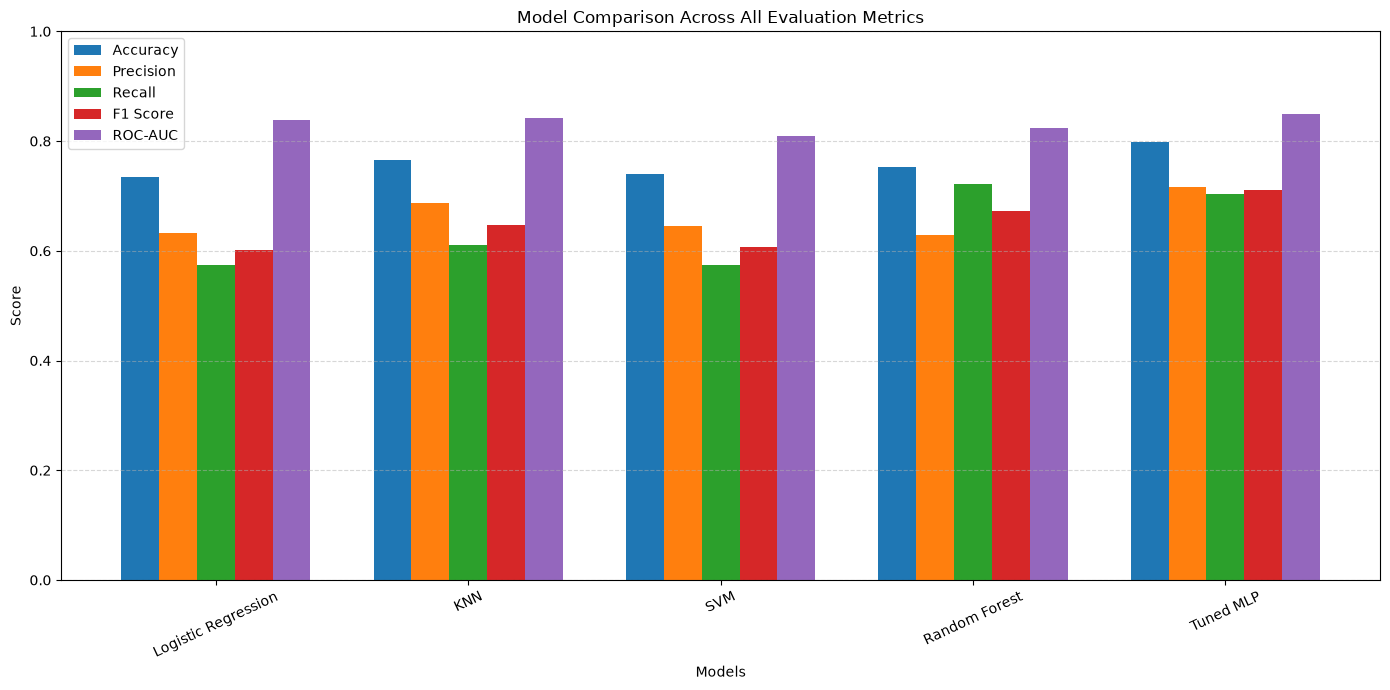

In [123]:
# Visual Comparison of Model Performance in a Single Graph

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

x = np.arange(len(model_results["Model"]))
width = 0.15

plt.figure(figsize=(14, 7))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 2) * width,
        model_results[metric],
        width,
        label=metric
    )

plt.title("Model Comparison Across All Evaluation Metrics")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    x,
    model_results["Model"],
    rotation=25
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

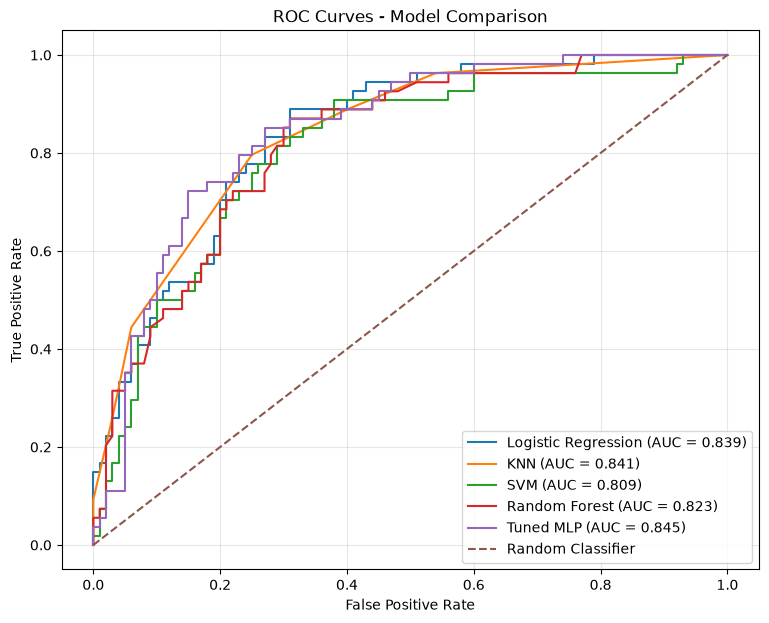

In [110]:
# ROC Curves for All Five Models

# Probability predictions
logistic_prob = logistic_model.predict_proba(X_test_processed)[:, 1]
knn_prob = knn_model.predict_proba(X_test_processed)[:, 1]
svm_prob = svm_model.predict_proba(X_test_processed)[:, 1]
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# MLP probability already available
mlp_prob = tuned_test_prob

# Calculate ROC curves
models_probabilities = {
    "Logistic Regression": logistic_prob,
    "KNN": knn_prob,
    "SVM": svm_prob,
    "Random Forest": rf_prob,
    "Tuned MLP": mlp_prob
}

plt.figure(figsize=(9, 7))

for model_name, probabilities in models_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

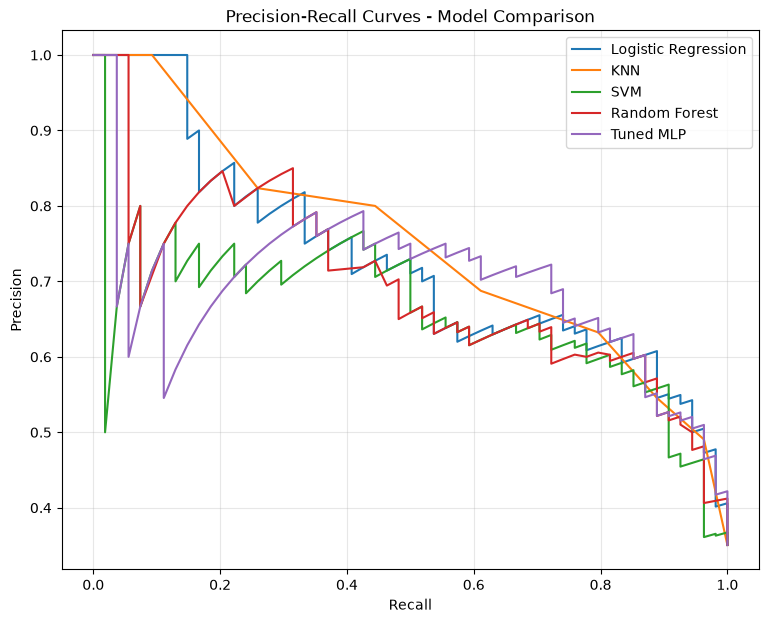

In [111]:
# Precision-Recall Curves for All Five Models

plt.figure(figsize=(9, 7))

for model_name, probabilities in models_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

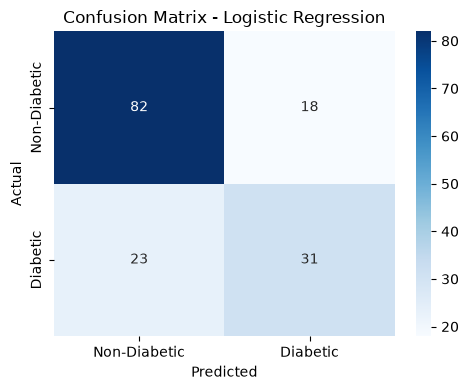

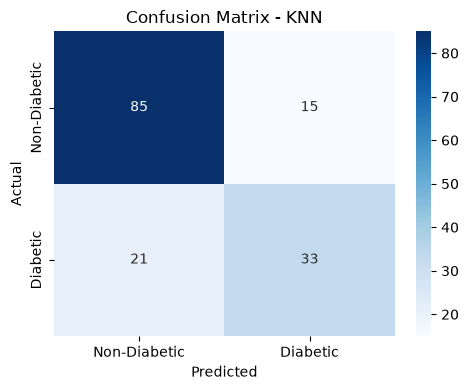

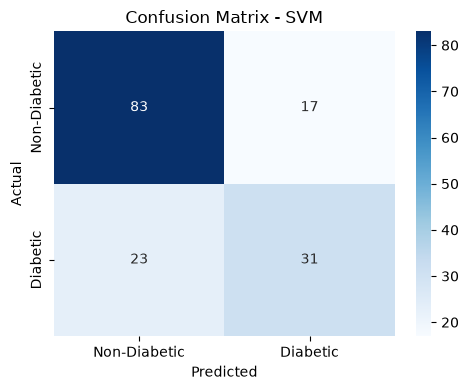

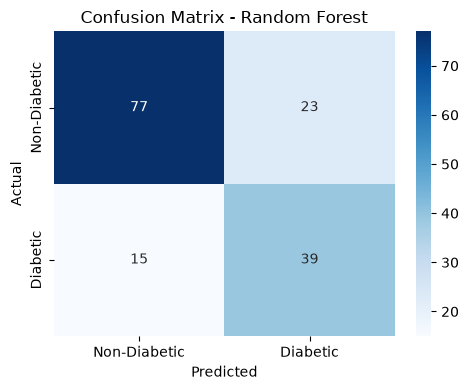

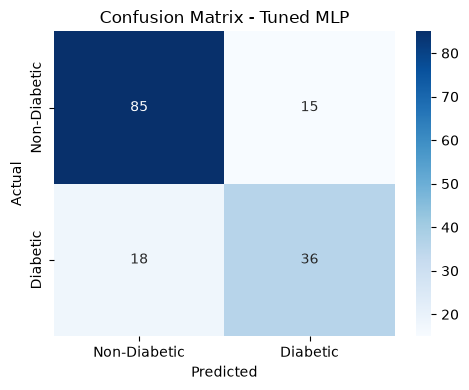

In [112]:
# Confusion Matrices for All Five Models

model_predictions = {
    "Logistic Regression": logistic_model.predict(X_test_processed),
    "KNN": knn_model.predict(X_test_processed),
    "SVM": svm_model.predict(X_test_processed),
    "Random Forest": rf_model.predict(X_test_processed),
    "Tuned MLP": final_mlp_pred
}

for model_name, predictions in model_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Diabetic", "Diabetic"],
        yticklabels=["Non-Diabetic", "Diabetic"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

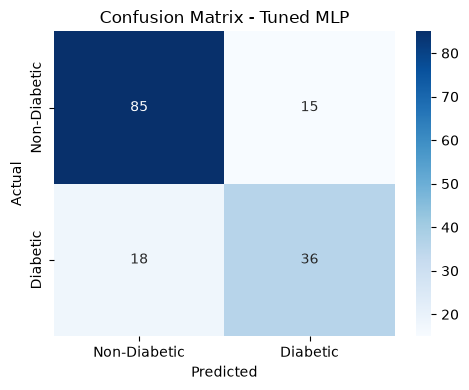

In [125]:
# Confusion Matrix for Tuned MLP

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, final_mlp_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.title("Confusion Matrix - Tuned MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

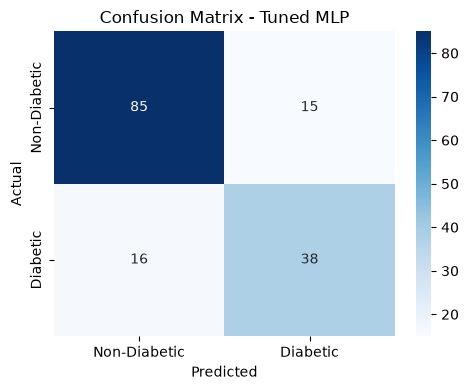

In [127]:
# Confusion Matrix - Tuned MLP

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix values
cm = np.array([
    [85, 15],
    [16, 38]
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.title("Confusion Matrix - Tuned MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [114]:
# Retrain Final Tuned MLP and Measure Training Time

import time

tf.random.set_seed(42)

final_mlp = Sequential([
    Input(shape=(X_mlp_train.shape[1],)),
    Dense(64, activation="relu",
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.30),
    Dense(32, activation="relu",
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

final_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

start_time = time.time()

final_history = final_mlp.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=150,
    batch_size=32,
    callbacks=[final_early_stopping],
    verbose=1
)

end_time = time.time()

mlp_training_time = end_time - start_time

print("\nFinal MLP training completed.")
print("Epochs trained:", len(final_history.history["loss"]))
print("Training time:", round(mlp_training_time, 2), "seconds")

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6517 - loss: 0.7073 - val_accuracy: 0.6504 - val_loss: 0.6615
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 0.6627 - val_accuracy: 0.7480 - val_loss: 0.6112
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6823 - loss: 0.6218 - val_accuracy: 0.8049 - val_loss: 0.5767
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7352 - loss: 0.5893 - val_accuracy: 0.8455 - val_loss: 0.5493
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7556 - loss: 0.5795 - val_accuracy: 0.7967 - val_loss: 0.5365
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7291 - loss: 0.5740 - val_accuracy: 0.7886 - val_loss: 0.5327
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7678 - loss: 0.5469 - val_accuracy: 0.7724 - val_loss: 0.5282
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7719 - loss: 0.5522 - val_accuracy: 0.7724 - 

In [115]:
# Model Performance Comparison

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest",
        "Tuned MLP"
    ],
    "Accuracy": [
        0.7338,
        0.7662,
        0.7403,
        0.7532,
        0.7987
    ],
    "Precision": [
        0.6327,
        0.6875,
        0.6458,
        0.6290,
        0.7170
    ],
    "Recall": [
        0.5741,
        0.6111,
        0.5741,
        0.7222,
        0.7037
    ],
    "F1 Score": [
        0.6019,
        0.6471,
        0.6078,
        0.6724,
        0.7103
    ],
    "ROC-AUC": [
        0.8387,
        0.8412,
        0.8085,
        0.8231,
        0.8496
    ],
    "Training Time (s)": [
        0.0294,
        0.2078,
        0.1110,
        1.2207,
        mlp_training_time
    ]
})

print(model_results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Training Time (s)
Logistic Regression    0.7338     0.6327  0.5741    0.6019   0.8387             0.0294
                KNN    0.7662     0.6875  0.6111    0.6471   0.8412             0.2078
                SVM    0.7403     0.6458  0.5741    0.6078   0.8085             0.1110
      Random Forest    0.7532     0.6290  0.7222    0.6724   0.8231             1.2207
          Tuned MLP    0.7987     0.7170  0.7037    0.7103   0.8496             7.0272


In [116]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [117]:
# Save the final trained MLP model

model_path = "../models/diabetes_mlp.keras"

final_mlp.save(model_path)

print("MLP model saved successfully!")
print("Path:", model_path)

MLP model saved successfully!
Path: ../models/diabetes_mlp.keras


In [118]:
import joblib

preprocessor_path = "../models/diabetes_preprocessor.joblib"

joblib.dump(final_preprocessor, preprocessor_path)

print("Preprocessor saved successfully!")
print("Path:", preprocessor_path)

Preprocessor saved successfully!
Path: ../models/diabetes_preprocessor.joblib


In [119]:
import os

print("Saved model files:")

for file in os.listdir("../models"):
    print("-", file)

Saved model files:
- diabetes_mlp.keras
- diabetes_preprocessor.joblib


In [120]:
dataset_features = pd.DataFrame({
    "Feature": [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ],
    "Data Type": [
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Binary (0/1)"
    ],
    "Description": [
        "Number of pregnancies",
        "Plasma glucose level (mg/dL)",
        "Diastolic blood pressure (mm Hg)",
        "Triceps skin fold thickness (mm)",
        "2-hour serum insulin (μU/mL)",
        "Body mass index",
        "Family history-based diabetes likelihood",
        "Patient age (years)",
        "Diabetes outcome: 1 = diabetic, 0 = non-diabetic"
    ],
    "Role": [
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Predictor",
        "Target"
    ]
})

dataset_features

,Feature,Data Type,Description,Role
0,Pregnancies,Numerical,Number of pregnancies,Predictor
1,Glucose,Numerical,Plasma glucose level (mg/dL),Predictor
2,BloodPressure,Numerical,Diastolic blood pressure (mm Hg),Predictor
3,SkinThickness,Numerical,Triceps skin fold thickness (mm),Predictor
4,Insulin,Numerical,2-hour serum insulin (μU/mL),Predictor
5,BMI,Numerical,Body mass index,Predictor
6,DiabetesPedigreeFunction,Numerical,Family history-based diabetes likelihood,Predictor
7,Age,Numerical,Patient age (years),Predictor
8,Outcome,Binary (0/1),"Diabetes outcome: 1 = diabetic, 0 = non-diabetic",Target


In [122]:
# Hyperparameters Considered and Selected

hyperparameters = pd.DataFrame({
    "Parameter": [
        "Hidden Layers",
        "Neurons per Layer",
        "Learning Rate",
        "Batch Size",
        "Activation",
        "Optimizer",
        "Dropout"
    ],

    "Values Tried": [
        "1, 2, 3",
        "16, 32, 64, 128",
        "0.001, 0.0005, 0.01",
        "16, 32, 64",
        "ReLU, Tanh",
        "Adam, RMSprop",
        "0.0, 0.2, 0.3, 0.5"
    ],

    "Selected": [
        "3",
        "64, 32, 16",
        "0.001",
        "32",
        "ReLU",
        "Adam",
        "0.30, 0.20"
    ]
})

display(hyperparameters)

,Parameter,Values Tried,Selected
0,Hidden Layers,"1, 2, 3",3
1,Neurons per Layer,"16, 32, 64, 128","64, 32, 16"
2,Learning Rate,"0.001, 0.0005, 0.01",0.001
3,Batch Size,"16, 32, 64",32
4,Activation,"ReLU, Tanh",ReLU
5,Optimizer,"Adam, RMSprop",Adam
6,Dropout,"0.0, 0.2, 0.3, 0.5","0.30, 0.20"


In [129]:
# Create a test patient

patient = pd.DataFrame([{
    "Pregnancies": 1,
    "Glucose": 90,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 80,
    "BMI": 22.5,
    "DiabetesPedigreeFunction": 0.25,
    "Age": 25,
    "AgeGroup": "Young",
    "BMICategory": "Normal",
    "GlucoseLevel": "Normal",
    "Glucose_BMI": 90 * 22.5,
    "Glucose_Age": 90 * 25,
    "BMI_Age": 22.5 * 25,
    "Insulin_log": np.log1p(80)
}])

# Apply the same preprocessing used during training
patient_processed = final_preprocessor.transform(patient)

print("Patient processed successfully.")
print("Processed shape:", patient_processed.shape)

Patient processed successfully.
Processed shape: (1, 22)


In [130]:
# Get probability of diabetes
probability = final_mlp.predict(
    patient_processed,
    verbose=0
)[0][0]

print("Diabetes probability:", round(probability * 100, 2), "%")

Diabetes probability: 0.17 %


In [131]:
# Create a likely diabetic test patient

patient = pd.DataFrame([{
    "Pregnancies": 6,
    "Glucose": 170,
    "BloodPressure": 90,
    "SkinThickness": 35,
    "Insulin": 200,
    "BMI": 38.0,
    "DiabetesPedigreeFunction": 0.80,
    "Age": 50,
    "AgeGroup": "Middle",
    "BMICategory": "Obese",
    "GlucoseLevel": "High",
    "Glucose_BMI": 170 * 38.0,
    "Glucose_Age": 170 * 50,
    "BMI_Age": 38.0 * 50,
    "Insulin_log": np.log1p(200)
}])

patient_processed = final_preprocessor.transform(patient)

probability = final_mlp.predict(
    patient_processed,
    verbose=0
)[0][0]

prediction = "Diabetic" if probability >= 0.50 else "Non-diabetic"

print("Prediction:", prediction)
print("Diabetes probability:", round(probability * 100, 2), "%")

Prediction: Diabetic
Diabetes probability: 78.11 %


In [132]:
# Create a borderline test patient

patient = pd.DataFrame([{
    "Pregnancies": 3,
    "Glucose": 125,
    "BloodPressure": 75,
    "SkinThickness": 25,
    "Insulin": 100,
    "BMI": 30.0,
    "DiabetesPedigreeFunction": 0.45,
    "Age": 35,
    "AgeGroup": "Middle",
    "BMICategory": "Obese",
    "GlucoseLevel": "Prediabetes",
    "Glucose_BMI": 125 * 30.0,
    "Glucose_Age": 125 * 35,
    "BMI_Age": 30.0 * 35,
    "Insulin_log": np.log1p(100)
}])

patient_processed = final_preprocessor.transform(patient)

probability = final_mlp.predict(
    patient_processed,
    verbose=0
)[0][0]

prediction = "Diabetic" if probability >= 0.50 else "Non-diabetic"

print("Prediction:", prediction)
print("Diabetes probability:", round(probability * 100, 2), "%")

Prediction: Diabetic
Diabetes probability: 56.45 %
